# Notebook 10: Gaze geometry and apparent orientation drift

## 1. Purpose

This notebook estimates geometry-induced apparent orientation drift under gaze drift and display correction mismatch, assuming stable underlying neural tuning.

The question is whether a neuron with stable orientation tuning could appear to drift because gaze samples different parts of a flat display and because the displayed grating has either no spherical correction, correct spherical-to-screen correction, or correction based on an incorrect screen distance.

The physically explicit interpretation used here is:

- A desired drifting grating is defined in eye-centered visual-angle coordinates.
- BonVision-style correction maps that intended stimulus onto a flat screen using an assumed display geometry.
- The eye then views the resulting flat-screen image under the true geometry.
- If the assumed geometry is wrong, the local line orientation in visual coordinates can differ from the intended orientation.

For the no-correction case, the grating is instead drawn directly on the flat screen with constant screen-plane orientation, then evaluated in visual coordinates at the eye. This is intentionally different from the corrected cases. If earlier logic treated these as the same operation, that interpretation is physically inconsistent with a forward display model.

In [1]:
import math
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from IPython.display import display, Markdown

CONFIG = dict(
    screen_width_cm=20.1,
    screen_height_cm=15.4,
    screen_center_xyz_cm=np.array([0.0, 3.3, -11.0]),
    true_distance_cm=11.0,
    assumed_distances_cm=[None, 11.0, 6.0, 16.0],  # None = no correction
    assumed_distance_labels=["no_correction", "correct_11cm", "under_6cm", "over_16cm"],
    canonical_orientations_deg=[0.0, 45.0, 90.0, 135.0],
    n_screen_x=161,
    n_screen_y=121,
    finite_diff_cm=0.05,
    n_sessions=8,
    max_gaze_drift_deg=10.0,
    n_neurons=1000,
    rf_patch_radius_deg=5.0,
    resting_jitter_relaxation=0.55,
    resting_jitter_fraction=0.22,
    random_seed=7,
    output_dir="results/notebook_10",
)

np.random.seed(CONFIG["random_seed"])

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 200,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 9,
    }
)

## 2. Geometry definition

Coordinate convention used throughout:

- The eye is at the world origin `(0, 0, 0)`.
- The screen plane is parallel to the `XY` plane.
- The true screen center is `(0, +3.3, -11)` cm.
- Screen width is along world `X`; screen height is along world `Y`.
- The nominal viewing direction is along negative `Z`.

The distance mismatch conditions change only the assumed screen-plane depth used by the correction algorithm: `Z=-6`, `Z=-11`, or `Z=-16` cm. The vertical offset remains `Y=+3.3` cm. Thus, "11 cm" means the depth of the plane along the negative-Z axis, matching the Bonsai / BonVision translation value, not the Euclidean distance from eye to screen center.

In [2]:
@dataclass(frozen=True)
class ScreenGeometry:
    """Flat screen geometry in eye-centered world coordinates."""

    width_cm: float
    height_cm: float
    center_xyz_cm: np.ndarray


def make_output_dirs(config):
    """Create output and cache directories used by this notebook."""
    output_dir = Path(config["output_dir"])
    cache_dir = output_dir / "cache"
    output_dir.mkdir(parents=True, exist_ok=True)
    cache_dir.mkdir(parents=True, exist_ok=True)
    return output_dir, cache_dir


def geometry_from_config(config, assumed_distance_cm=None):
    """Return a ScreenGeometry, optionally replacing the screen depth."""
    center = np.array(config["screen_center_xyz_cm"], dtype=float).copy()
    if assumed_distance_cm is not None:
        center[2] = -float(assumed_distance_cm)
    return ScreenGeometry(
        width_cm=float(config["screen_width_cm"]),
        height_cm=float(config["screen_height_cm"]),
        center_xyz_cm=center,
    )


def ori_diff_deg(a, b):
    """Return unsigned orientation difference in degrees, modulo 180."""
    d = np.abs(a - b) % 180.0
    return np.minimum(d, 180.0 - d)


def signed_ori_diff_deg(a, b):
    """Return signed orientation difference a - b in degrees in [-90, 90)."""
    return ((np.asarray(a) - np.asarray(b) + 90.0) % 180.0) - 90.0


def wrap_ori_deg(a):
    """Wrap line orientation to [0, 180)."""
    return np.asarray(a) % 180.0


def screen_grid_cm(config):
    """Return screen-local x/y axes and 2D mesh grids in centimeters."""
    xs = np.linspace(
        -config["screen_width_cm"] / 2.0,
        config["screen_width_cm"] / 2.0,
        int(config["n_screen_x"]),
    )
    ys = np.linspace(
        -config["screen_height_cm"] / 2.0,
        config["screen_height_cm"] / 2.0,
        int(config["n_screen_y"]),
    )
    X, Y = np.meshgrid(xs, ys)
    return xs, ys, X, Y


def screen_point_world(x_cm, y_cm, config):
    """Convert screen-local coordinates in cm to world XYZ coordinates."""
    center = np.asarray(config["screen_center_xyz_cm"], dtype=float)
    x = np.asarray(x_cm, dtype=float)
    y = np.asarray(y_cm, dtype=float)
    return np.stack(
        [
            center[0] + x,
            center[1] + y,
            np.zeros_like(x, dtype=float) + center[2],
        ],
        axis=-1,
    )


output_dir, cache_dir = make_output_dirs(CONFIG)
true_geometry = geometry_from_config(CONFIG)
true_geometry

ScreenGeometry(width_cm=20.1, height_cm=15.4, center_xyz_cm=array([  0. ,   3.3, -11. ]))

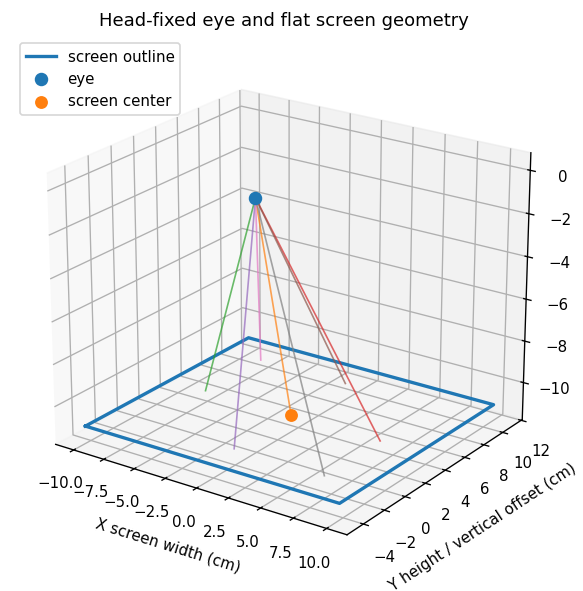

PosixPath('results/notebook_10/setup_geometry.png')

In [3]:
def plot_setup_geometry(config, output_dir):
    """Draw the eye, screen outline, screen center, and example rays."""
    geom = geometry_from_config(config)
    w = geom.width_cm
    h = geom.height_cm
    cx, cy, cz = geom.center_xyz_cm

    corners = np.array(
        [
            [cx - w / 2, cy - h / 2, cz],
            [cx + w / 2, cy - h / 2, cz],
            [cx + w / 2, cy + h / 2, cz],
            [cx - w / 2, cy + h / 2, cz],
            [cx - w / 2, cy - h / 2, cz],
        ]
    )
    sample_local = np.array(
        [
            [0.0, 0.0],
            [-0.35 * w, 0.0],
            [0.35 * w, 0.0],
            [0.0, -0.35 * h],
            [0.0, 0.35 * h],
            [-0.35 * w, 0.35 * h],
            [0.35 * w, -0.35 * h],
        ]
    )
    sample_world = screen_point_world(sample_local[:, 0], sample_local[:, 1], config)

    fig = plt.figure(figsize=(6.5, 5.0))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(corners[:, 0], corners[:, 1], corners[:, 2], lw=2, label="screen outline")
    ax.scatter([0], [0], [0], s=50, label="eye")
    ax.scatter([cx], [cy], [cz], s=45, label="screen center")
    for p in sample_world:
        ax.plot([0, p[0]], [0, p[1]], [0, p[2]], lw=1, alpha=0.7)
    ax.set_xlabel("X screen width (cm)")
    ax.set_ylabel("Y height / vertical offset (cm)")
    ax.set_zlabel("Z depth (cm)")
    ax.set_title("Head-fixed eye and flat screen geometry")
    ax.legend(loc="upper left")
    ax.view_init(elev=22, azim=-55)
    ax.set_box_aspect((1.1, 1.0, 0.9))
    fig.tight_layout()
    path = output_dir / "setup_geometry.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    return path


setup_path = plot_setup_geometry(CONFIG, output_dir)
setup_path

## 3. Screen-to-visual mapping

Visual direction is represented by azimuth and elevation in degrees:

- `azimuth = atan2(X, -Z)`, positive to the right on the screen.
- `elevation = atan2(Y, sqrt(X^2 + Z^2))`, positive upward.

The inverse uses unit rays
`ray = (cos(el) sin(az), sin(el), -cos(el) cos(az))`.
Intersections are computed with the screen plane at fixed `Z`.

In [4]:
def world_to_view_angles(xyz):
    """Convert world XYZ point(s) to eye-centered azimuth/elevation degrees."""
    xyz = np.asarray(xyz, dtype=float)
    x = xyz[..., 0]
    y = xyz[..., 1]
    z = xyz[..., 2]
    az = np.degrees(np.arctan2(x, -z))
    el = np.degrees(np.arctan2(y, np.sqrt(x * x + z * z)))
    return az, el


def view_angles_to_ray(az_deg, el_deg):
    """Convert azimuth/elevation degrees to unit ray direction(s)."""
    az = np.radians(az_deg)
    el = np.radians(el_deg)
    ray = np.stack(
        [
            np.cos(el) * np.sin(az),
            np.sin(el),
            -np.cos(el) * np.cos(az),
        ],
        axis=-1,
    )
    norm = np.linalg.norm(ray, axis=-1, keepdims=True)
    return ray / norm


def intersect_ray_with_screen(
    ray_origin,
    ray_dir,
    screen_center_xyz_cm,
    screen_width_cm,
    screen_height_cm,
):
    """Intersect ray(s) with the flat screen plane.

    Returns `(xyz, xy_cm, in_bounds)`.
    `xy_cm` is in screen-local cm relative to the supplied screen center.
    Intersections outside the finite rectangle are still returned, with
    `in_bounds=False`, because local differential calculations near edges
    need the tangent plane even when finite-difference points cross the border.
    """
    origin = np.asarray(ray_origin, dtype=float)
    direction = np.asarray(ray_dir, dtype=float)
    center = np.asarray(screen_center_xyz_cm, dtype=float)
    z_plane = center[2]
    denom = direction[..., 2]
    valid = np.abs(denom) > 1e-12
    t = (z_plane - origin[..., 2]) / denom
    valid = valid & (t > 0)
    xyz = origin + direction * np.expand_dims(t, axis=-1)
    xy = np.stack([xyz[..., 0] - center[0], xyz[..., 1] - center[1]], axis=-1)
    in_bounds = (
        valid
        & (np.abs(xy[..., 0]) <= screen_width_cm / 2.0)
        & (np.abs(xy[..., 1]) <= screen_height_cm / 2.0)
    )
    xyz = np.where(np.expand_dims(valid, axis=-1), xyz, np.nan)
    xy = np.where(np.expand_dims(valid, axis=-1), xy, np.nan)
    return xyz, xy, in_bounds


def screen_to_view_angles_with_geometry(x_cm, y_cm, geometry):
    """Map screen-local cm coordinates to visual azimuth/elevation for a geometry."""
    x = np.asarray(x_cm, dtype=float)
    y = np.asarray(y_cm, dtype=float)
    center = np.asarray(geometry.center_xyz_cm, dtype=float)
    xyz = np.stack(
        [
            center[0] + x,
            center[1] + y,
            np.zeros_like(x, dtype=float) + center[2],
        ],
        axis=-1,
    )
    return world_to_view_angles(xyz)


def screen_to_view_angles(x_cm, y_cm, config):
    """Map true screen-local cm coordinates to visual azimuth/elevation degrees."""
    return screen_to_view_angles_with_geometry(x_cm, y_cm, geometry_from_config(config))


def view_angles_to_screen_xy(az_deg, el_deg, geometry):
    """Intersect visual directions with a supplied screen geometry."""
    ray = view_angles_to_ray(az_deg, el_deg)
    _, xy, in_bounds = intersect_ray_with_screen(
        np.array([0.0, 0.0, 0.0]),
        ray,
        geometry.center_xyz_cm,
        geometry.width_cm,
        geometry.height_cm,
    )
    return xy[..., 0], xy[..., 1], in_bounds


center_az, center_el = screen_to_view_angles(0.0, 0.0, CONFIG)
expected_center_el = np.degrees(
    np.arctan2(CONFIG["screen_center_xyz_cm"][1], -CONFIG["screen_center_xyz_cm"][2])
)

print(f"Screen center azimuth: {center_az:.4f} deg")
print(f"Screen center elevation: {center_el:.4f} deg")
print(f"Expected center azimuth/elevation: 0.0000 deg, {expected_center_el:.4f} deg")

Screen center azimuth: 0.0000 deg
Screen center elevation: 16.6992 deg
Expected center azimuth/elevation: 0.0000 deg, 16.6992 deg


## 4. Local orientation transform

The local orientation model is differential and numerical. At each screen position, the notebook estimates the Jacobian from screen coordinates `(x_cm, y_cm)` to visual coordinates `(az_deg, el_deg)` by central finite differences. A line orientation is represented by a small direction vector, then pushed through or pulled back through the Jacobian.

This keeps the two correction steps distinct:

- No correction: screen line direction is chosen directly in screen coordinates and pushed through the true screen-to-visual Jacobian.
- Corrected conditions: intended visual line direction is pulled back through the assumed-geometry Jacobian to get the drawn screen line direction; that screen line is then pushed through the true-geometry Jacobian to determine what the eye sees.

In [5]:
def screen_to_visual_jacobian(x_cm, y_cm, geometry, finite_diff_cm):
    """Numerically estimate d(az, el) / d(x_cm, y_cm) at screen point(s)."""
    x = np.asarray(x_cm, dtype=float)
    y = np.asarray(y_cm, dtype=float)
    h = float(finite_diff_cm)

    az_xp, el_xp = screen_to_view_angles_with_geometry(x + h, y, geometry)
    az_xm, el_xm = screen_to_view_angles_with_geometry(x - h, y, geometry)
    az_yp, el_yp = screen_to_view_angles_with_geometry(x, y + h, geometry)
    az_ym, el_ym = screen_to_view_angles_with_geometry(x, y - h, geometry)

    jaz_x = (az_xp - az_xm) / (2.0 * h)
    jel_x = (el_xp - el_xm) / (2.0 * h)
    jaz_y = (az_yp - az_ym) / (2.0 * h)
    jel_y = (el_yp - el_ym) / (2.0 * h)

    return np.stack(
        [
            np.stack([jaz_x, jaz_y], axis=-1),
            np.stack([jel_x, jel_y], axis=-1),
        ],
        axis=-2,
    )


def local_orientation_on_screen_from_visual_orientation(
    x_cm,
    y_cm,
    ori_visual_deg,
    assumed_distance_cm,
    config,
):
    """Return the local screen-plane orientation that an assumed correction draws.

    Parameters
    ----------
    x_cm, y_cm : scalar or array
        Screen-local coordinates at which to evaluate the local transform.
    ori_visual_deg : scalar or array
        Intended line orientation in azimuth/elevation coordinates, in degrees.
    assumed_distance_cm : float or None
        Assumed screen depth used by the correction. `None` represents the
        no-correction case and returns the same numerical orientation on the screen.
    config : dict
        Notebook configuration.
    """
    if assumed_distance_cm is None:
        return wrap_ori_deg(np.asarray(ori_visual_deg, dtype=float))

    assumed_geometry = geometry_from_config(config, assumed_distance_cm)
    J = screen_to_visual_jacobian(
        x_cm,
        y_cm,
        assumed_geometry,
        config["finite_diff_cm"],
    )

    theta = np.radians(ori_visual_deg)
    v_az = np.cos(theta)
    v_el = np.sin(theta)

    a = J[..., 0, 0]
    b = J[..., 0, 1]
    c = J[..., 1, 0]
    d = J[..., 1, 1]
    det = a * d - b * c

    sx = (d * v_az - b * v_el) / det
    sy = (-c * v_az + a * v_el) / det
    return wrap_ori_deg(np.degrees(np.arctan2(sy, sx)))


def local_visual_orientation_from_screen_orientation(x_cm, y_cm, ori_screen_deg, config):
    """Return the visual orientation produced by a local screen-plane line."""
    true_geometry = geometry_from_config(config)
    J = screen_to_visual_jacobian(
        x_cm,
        y_cm,
        true_geometry,
        config["finite_diff_cm"],
    )
    theta = np.radians(ori_screen_deg)
    sx = np.cos(theta)
    sy = np.sin(theta)
    v_az = J[..., 0, 0] * sx + J[..., 0, 1] * sy
    v_el = J[..., 1, 0] * sx + J[..., 1, 1] * sy
    return wrap_ori_deg(np.degrees(np.arctan2(v_el, v_az)))


def condition_to_distance(condition, config):
    """Convert a condition label or distance to `(label, assumed_distance_cm)`."""
    labels = list(config["assumed_distance_labels"])
    distances = list(config["assumed_distances_cm"])
    if isinstance(condition, str):
        if condition not in labels:
            raise ValueError(f"Unknown condition label: {condition}")
        idx = labels.index(condition)
        return labels[idx], distances[idx]
    if condition is None:
        return labels[0], None
    if isinstance(condition, (int, float)):
        if float(condition) in distances:
            idx = distances.index(float(condition))
            return labels[idx], distances[idx]
        return f"assumed_{condition:g}cm", float(condition)
    if isinstance(condition, dict):
        return condition["label"], condition["assumed_distance_cm"]
    raise TypeError("condition must be a label, distance, None, or dict")


def compute_orientation_error_surface(condition, ori_deg, config):
    """Compute orientation mismatch surface for a correction condition and orientation."""
    label, assumed_distance_cm = condition_to_distance(condition, config)
    xs, ys, X, Y = screen_grid_cm(config)

    if assumed_distance_cm is None:
        screen_ori = np.zeros_like(X, dtype=float) + ori_deg
    else:
        screen_ori = local_orientation_on_screen_from_visual_orientation(
            X,
            Y,
            ori_deg,
            assumed_distance_cm,
            config,
        )

    actual_visual_ori = local_visual_orientation_from_screen_orientation(
        X,
        Y,
        screen_ori,
        config,
    )
    signed_error = signed_ori_diff_deg(actual_visual_ori, ori_deg)
    abs_error = ori_diff_deg(actual_visual_ori, ori_deg)
    return dict(
        condition=label,
        assumed_distance_cm=assumed_distance_cm,
        ori_deg=float(ori_deg),
        xs=xs,
        ys=ys,
        X=X,
        Y=Y,
        screen_orientation_deg=screen_ori,
        actual_visual_orientation_deg=actual_visual_ori,
        signed_error_deg=signed_error,
        error_deg=abs_error,
    )


# Quick local transform sanity check at the screen center.
for ori in CONFIG["canonical_orientations_deg"]:
    no_corr_actual = local_visual_orientation_from_screen_orientation(0.0, 0.0, ori, CONFIG)
    corr_screen = local_orientation_on_screen_from_visual_orientation(0.0, 0.0, ori, 11.0, CONFIG)
    corr_actual = local_visual_orientation_from_screen_orientation(0.0, 0.0, corr_screen, CONFIG)
    print(
        f"ori {ori:5.1f} deg | no-corr actual {float(no_corr_actual):7.3f} deg | "
        f"correct screen draw {float(corr_screen):7.3f} deg | correct actual {float(corr_actual):7.3f} deg"
    )

ori   0.0 deg | no-corr actual   0.000 deg | correct screen draw   0.000 deg | correct actual   0.000 deg
ori  45.0 deg | no-corr actual  42.534 deg | correct screen draw  47.466 deg | correct actual  45.000 deg
ori  90.0 deg | no-corr actual  90.000 deg | correct screen draw  90.000 deg | correct actual  90.000 deg
ori 135.0 deg | no-corr actual 137.466 deg | correct screen draw 132.534 deg | correct actual 135.000 deg


## 5. Orientation error surfaces

Each surface shows unsigned orientation mismatch in degrees:

`mismatch = intended local orientation in visual space - actual local orientation seen by the eye`, modulo 180 degrees.

The saved maps use screen-local centimeters on the axes. The `correct_11cm` condition should be near zero everywhere because the same geometry is used to render and evaluate the stimulus. The no-correction and wrong-distance conditions can produce spatially varying mismatch, which is what can become apparent drift when gaze samples different screen locations across sessions.

In [6]:
surface_results = {}

for label in CONFIG["assumed_distance_labels"]:
    for ori in CONFIG["canonical_orientations_deg"]:
        surface_results[(label, float(ori))] = compute_orientation_error_surface(label, ori, CONFIG)

surface_stats = []
for (label, ori), result in surface_results.items():
    err = result["error_deg"]
    surface_stats.append(
        dict(
            condition=label,
            orientation_deg=ori,
            median_error_deg=float(np.nanmedian(err)),
            p95_error_deg=float(np.nanpercentile(err, 95)),
            max_error_deg=float(np.nanmax(err)),
        )
    )

surface_stats_df = pd.DataFrame(surface_stats)
display(surface_stats_df)

,condition,orientation_deg,median_error_deg,p95_error_deg,max_error_deg
0,no_correction,0.0,5.715755e+00,1.865710e+01,2.358416e+01
1,no_correction,45.0,4.535428e+00,1.874092e+01,2.456757e+01
2,no_correction,90.0,0.000000e+00,0.000000e+00,0.000000e+00
3,no_correction,135.0,4.535428e+00,1.874092e+01,2.456757e+01
4,correct_11cm,0.0,0.000000e+00,4.891196e-15,2.842171e-14
5,correct_11cm,45.0,7.105427e-15,1.421085e-14,2.842171e-14
6,correct_11cm,90.0,0.000000e+00,0.000000e+00,0.000000e+00
7,correct_11cm,135.0,0.000000e+00,2.842171e-14,5.684342e-14
8,under_6cm,0.0,7.726670e+00,1.665803e+01,1.771143e+01
9,under_6cm,45.0,6.336027e+00,1.599907e+01,2.083205e+01


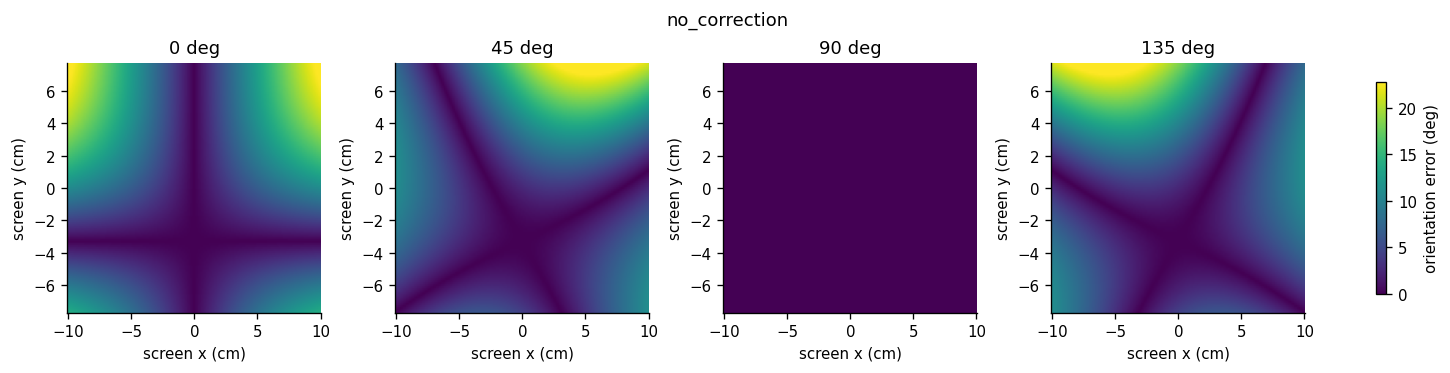

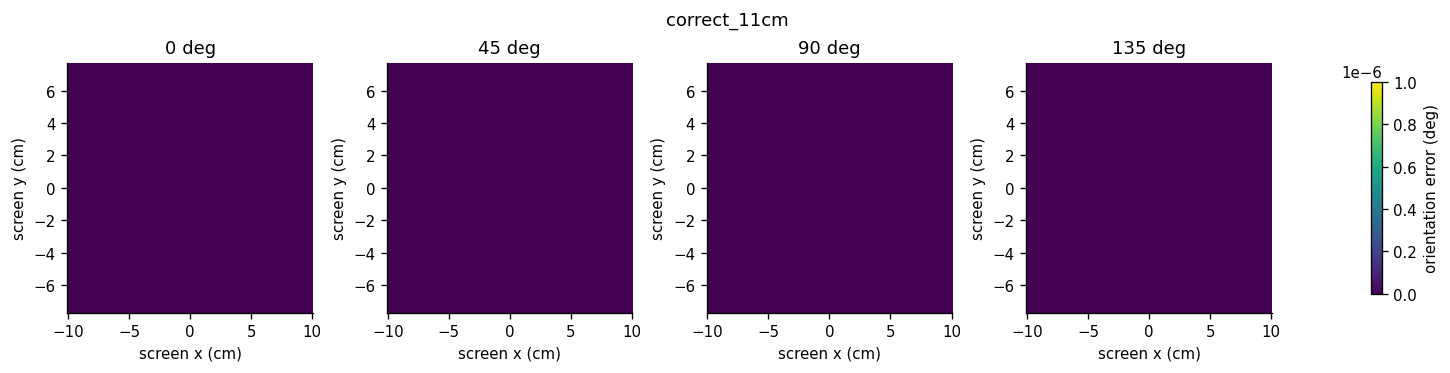

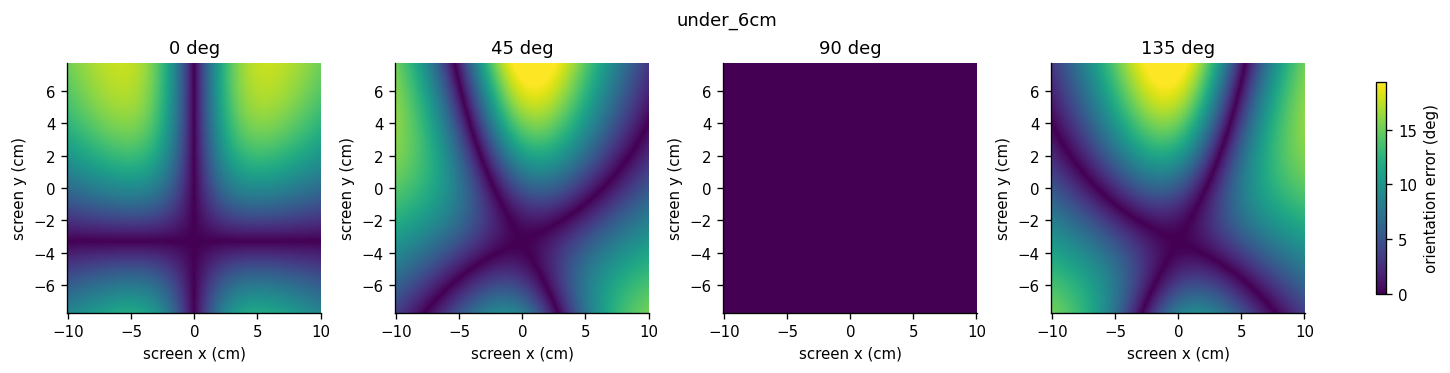

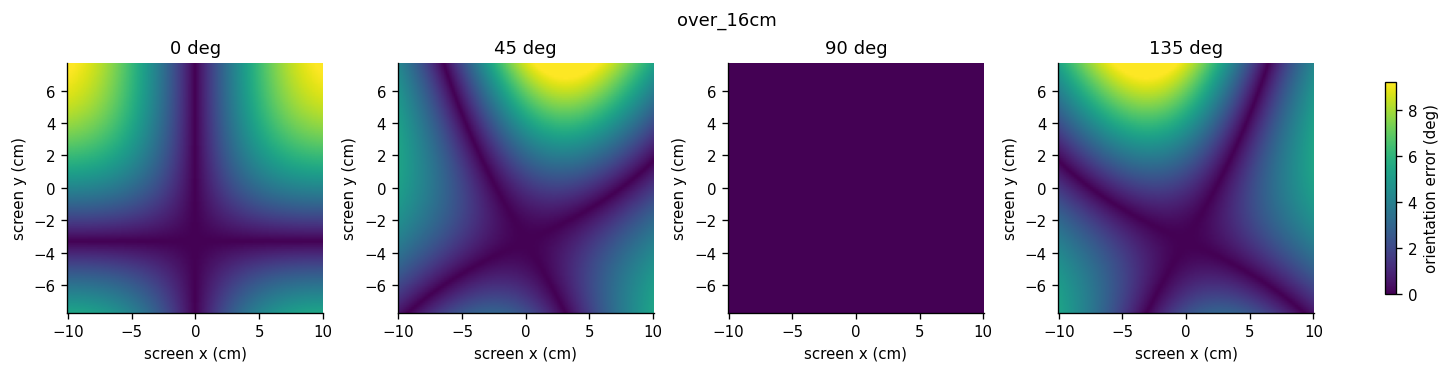

{'no_correction': PosixPath('results/notebook_10/error_surface_no_correction.png'),
 'correct_11cm': PosixPath('results/notebook_10/error_surface_correct_11cm.png'),
 'under_6cm': PosixPath('results/notebook_10/error_surface_under_6cm.png'),
 'over_16cm': PosixPath('results/notebook_10/error_surface_over_16cm.png')}

In [7]:
def plot_error_panels_for_condition(label, surface_results, config, output_dir):
    """Save a one-row panel of error surfaces for one condition."""
    orientations = [float(v) for v in config["canonical_orientations_deg"]]
    vmax = max(
        np.nanpercentile(surface_results[(label, ori)]["error_deg"], 99)
        for ori in orientations
    )
    vmax = max(vmax, 1e-6)
    fig, axes = plt.subplots(1, len(orientations), figsize=(12.0, 3.0), constrained_layout=True)
    if len(orientations) == 1:
        axes = [axes]
    last_im = None
    for ax, ori in zip(axes, orientations):
        res = surface_results[(label, ori)]
        extent = [
            res["xs"][0],
            res["xs"][-1],
            res["ys"][0],
            res["ys"][-1],
        ]
        last_im = ax.imshow(
            res["error_deg"],
            origin="lower",
            extent=extent,
            aspect="auto",
            vmin=0,
            vmax=vmax,
        )
        ax.set_title(f"{ori:g} deg")
        ax.set_xlabel("screen x (cm)")
        ax.set_ylabel("screen y (cm)")
    fig.colorbar(last_im, ax=axes, shrink=0.85, label="orientation error (deg)")
    fig.suptitle(label)
    path = output_dir / f"error_surface_{label}.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    return path


error_surface_paths = {}
for label in CONFIG["assumed_distance_labels"]:
    error_surface_paths[label] = plot_error_panels_for_condition(label, surface_results, CONFIG, output_dir)

error_surface_paths

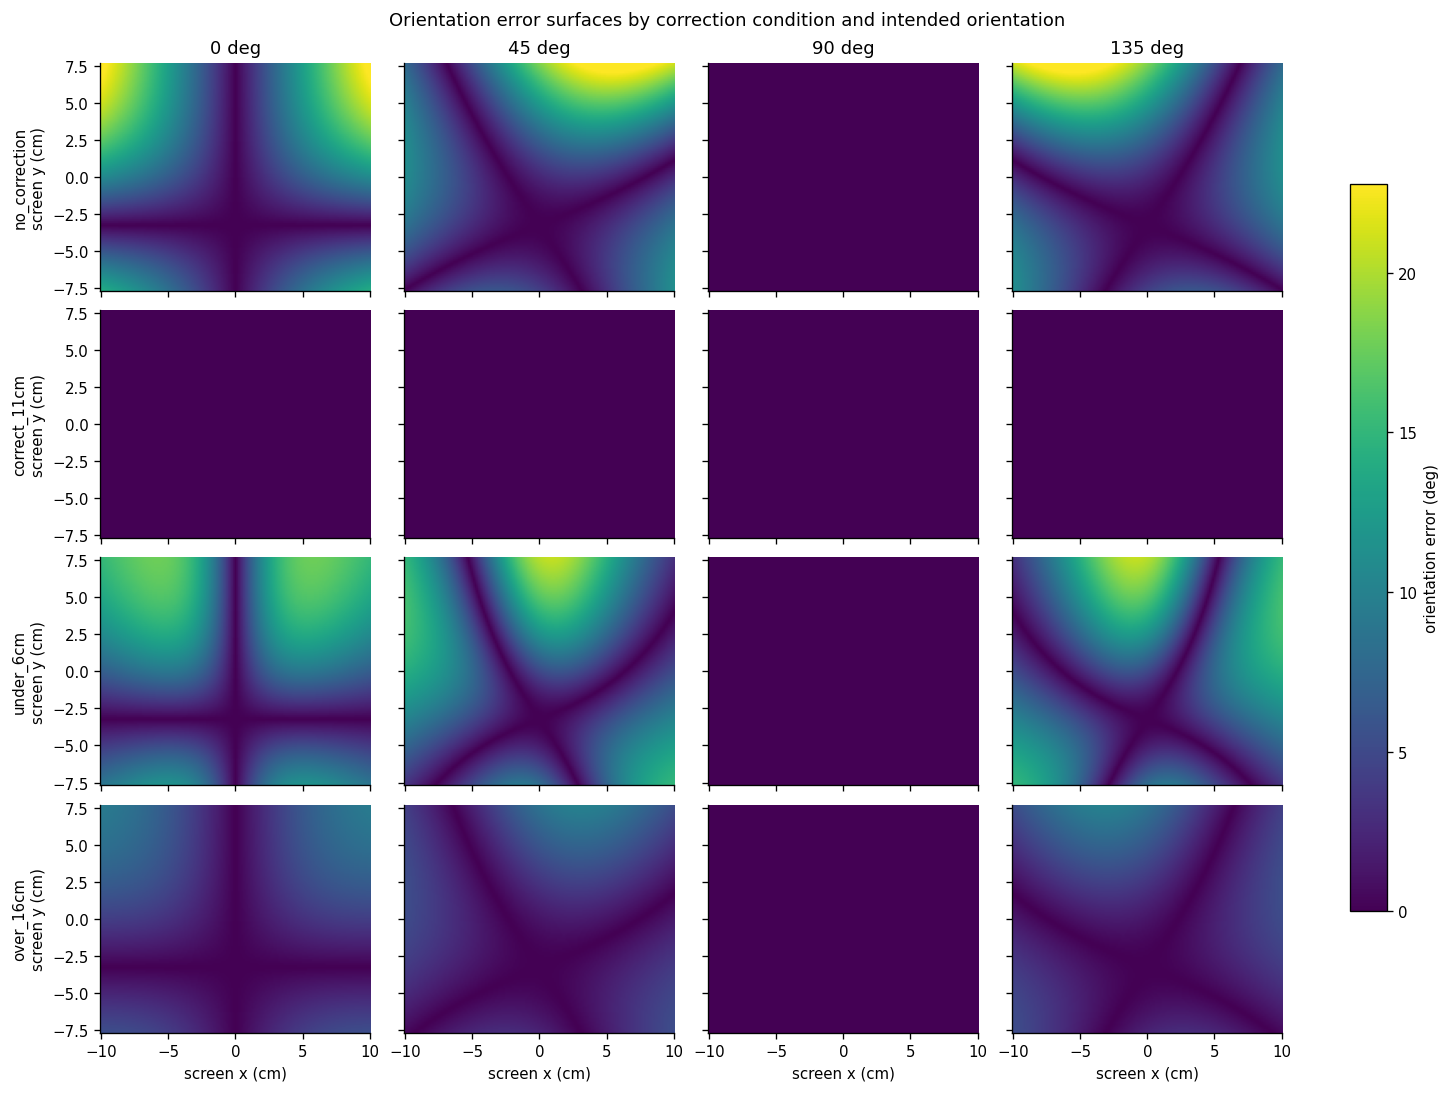

PosixPath('results/notebook_10/canonical_orientation_error_panels.png')

In [8]:
def plot_all_canonical_error_panels(surface_results, config, output_dir):
    """Save rows=conditions, columns=canonical orientations error panel."""
    labels = list(config["assumed_distance_labels"])
    orientations = [float(v) for v in config["canonical_orientations_deg"]]
    vmax = max(
        np.nanpercentile(surface_results[(label, ori)]["error_deg"], 99)
        for label in labels
        for ori in orientations
    )
    vmax = max(vmax, 1e-6)
    fig, axes = plt.subplots(
        len(labels),
        len(orientations),
        figsize=(12.0, 9.0),
        constrained_layout=True,
        sharex=True,
        sharey=True,
    )
    last_im = None
    for r, label in enumerate(labels):
        for c, ori in enumerate(orientations):
            ax = axes[r, c]
            res = surface_results[(label, ori)]
            extent = [res["xs"][0], res["xs"][-1], res["ys"][0], res["ys"][-1]]
            last_im = ax.imshow(
                res["error_deg"],
                origin="lower",
                extent=extent,
                aspect="auto",
                vmin=0,
                vmax=vmax,
            )
            if r == 0:
                ax.set_title(f"{ori:g} deg")
            if c == 0:
                ax.set_ylabel(f"{label}\nscreen y (cm)")
            if r == len(labels) - 1:
                ax.set_xlabel("screen x (cm)")
    fig.colorbar(last_im, ax=axes, shrink=0.75, label="orientation error (deg)")
    fig.suptitle("Orientation error surfaces by correction condition and intended orientation")
    path = output_dir / "canonical_orientation_error_panels.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    return path


canonical_panels_path = plot_all_canonical_error_panels(surface_results, CONFIG, output_dir)
canonical_panels_path

## 6. Gaze drift simulations

Gaze drift is represented as drift in viewing direction, in azimuth/elevation degrees. Each starting position is first defined as a location on the screen, converted to an eye-centered visual direction, then perturbed over sessions. The resulting visual directions are intersected with the true screen plane to determine which screen locations are sampled.

Three trajectory families are included:

- `monotonic`: linear drift across sessions.
- `random_walk`: cumulative random steps scaled to the requested maximum displacement.
- `resting_jitter`: gaze relaxes toward a preferred resting offset, then jitters around that offset with bounded session-to-session noise.

Drift magnitudes span 0 to 10 deg. Some extreme trajectories may partially leave the finite screen; those samples are retained with `in_bounds=False` and excluded from summaries requiring valid screen samples. The new `resting_jitter` family is intended to represent a mouse whose gaze has a preferred resting direction rather than diffusing indefinitely.

In [9]:
def starting_screen_positions(config):
    """Return named starting positions in screen-local cm."""
    w = config["screen_width_cm"]
    h = config["screen_height_cm"]
    return {
        "center": (0.0, 0.0),
        "upper": (0.0, 0.28 * h),
        "lower": (0.0, -0.28 * h),
        "left": (-0.28 * w, 0.0),
        "right": (0.28 * w, 0.0),
        "upper_left_biased": (-0.24 * w, 0.24 * h),
        "upper_right_biased": (0.24 * w, 0.24 * h),
        "lower_left_biased": (-0.24 * w, -0.24 * h),
        "lower_right_biased": (0.24 * w, -0.24 * h),
    }


def simulate_gaze_trajectories(config):
    """Simulate monotonic, random-walk, and resting-jitter gaze trajectories.

    Returns a DataFrame with visual-angle positions and corresponding true
    screen intersections for each trajectory.
    """
    rng = np.random.default_rng(config["random_seed"])
    n_sessions = int(config["n_sessions"])
    magnitudes = np.linspace(0.0, float(config["max_gaze_drift_deg"]), 5)
    starts = starting_screen_positions(config)
    true_geom = geometry_from_config(config)
    relax = float(config["resting_jitter_relaxation"])
    jitter_fraction = float(config["resting_jitter_fraction"])
    rows = []

    for start_idx, (start_label, (x0, y0)) in enumerate(starts.items()):
        az0, el0 = screen_to_view_angles(x0, y0, config)
        base_angle = 2.0 * np.pi * (start_idx / max(len(starts), 1)) + 0.35
        monotonic_dir = np.array([np.cos(base_angle), np.sin(base_angle)])

        for drift_mag in magnitudes:
            target = drift_mag * monotonic_dir
            jitter_scale = jitter_fraction * drift_mag
            for model in ["monotonic", "random_walk", "resting_jitter"]:
                if drift_mag == 0:
                    displacements = np.zeros((n_sessions, 2), dtype=float)
                elif model == "monotonic":
                    t = np.linspace(0.0, 1.0, n_sessions)
                    displacements = t[:, None] * drift_mag * monotonic_dir[None, :]
                elif model == "random_walk":
                    steps = rng.normal(size=(n_sessions - 1, 2))
                    step_norm = np.linalg.norm(steps, axis=1, keepdims=True)
                    steps = steps / np.maximum(step_norm, 1e-12)
                    cumulative = np.vstack([np.zeros((1, 2)), np.cumsum(steps, axis=0)])
                    cumulative = cumulative - cumulative[0]
                    max_radius = np.max(np.linalg.norm(cumulative, axis=1))
                    displacements = cumulative * (drift_mag / max(max_radius, 1e-12))
                else:
                    displacements = np.zeros((n_sessions, 2), dtype=float)
                    for session_idx in range(1, n_sessions):
                        noise = rng.normal(scale=jitter_scale, size=2)
                        proposal = (
                            relax * displacements[session_idx - 1]
                            + (1.0 - relax) * target
                            + noise
                        )
                        step_norm = np.linalg.norm(proposal - target)
                        max_offset = drift_mag + 2.0 * jitter_scale
                        if step_norm > max_offset:
                            proposal = target + (proposal - target) * (max_offset / step_norm)
                        displacements[session_idx] = proposal

                az = az0 + displacements[:, 0]
                el = el0 + displacements[:, 1]
                x, y, in_bounds = view_angles_to_screen_xy(az, el, true_geom)

                for session_idx in range(n_sessions):
                    rows.append(
                        dict(
                            model=model,
                            start_label=start_label,
                            start_x_cm=x0,
                            start_y_cm=y0,
                            drift_magnitude_deg=float(drift_mag),
                            session=session_idx + 1,
                            az_deg=float(az[session_idx]),
                            el_deg=float(el[session_idx]),
                            drift_az_deg=float(displacements[session_idx, 0]),
                            drift_el_deg=float(displacements[session_idx, 1]),
                            displacement_deg=float(np.linalg.norm(displacements[session_idx])),
                            x_cm=float(x[session_idx]),
                            y_cm=float(y[session_idx]),
                            in_bounds=bool(in_bounds[session_idx]),
                        )
                    )

    return pd.DataFrame(rows)


gaze_df = simulate_gaze_trajectories(CONFIG)
display(gaze_df.head())
display(
    gaze_df.groupby(["model", "drift_magnitude_deg"])["displacement_deg"]
    .agg(["median", "max"])
    .reset_index()
    .head(15)
)

,model,start_label,start_x_cm,start_y_cm,drift_magnitude_deg,session,az_deg,el_deg,drift_az_deg,drift_el_deg,displacement_deg,x_cm,y_cm,in_bounds
0,monotonic,center,0.0,0.0,0.0,1,0.0,16.699244,0.0,0.0,0.0,0.0,4.440892e-16,True
1,monotonic,center,0.0,0.0,0.0,2,0.0,16.699244,0.0,0.0,0.0,0.0,4.440892e-16,True
2,monotonic,center,0.0,0.0,0.0,3,0.0,16.699244,0.0,0.0,0.0,0.0,4.440892e-16,True
3,monotonic,center,0.0,0.0,0.0,4,0.0,16.699244,0.0,0.0,0.0,0.0,4.440892e-16,True
4,monotonic,center,0.0,0.0,0.0,5,0.0,16.699244,0.0,0.0,0.0,0.0,4.440892e-16,True


,model,drift_magnitude_deg,median,max
0,monotonic,0.0,0.000000,0.000000
1,monotonic,2.5,1.250000,2.500000
2,monotonic,5.0,2.500000,5.000000
3,monotonic,7.5,3.750000,7.500000
4,monotonic,10.0,5.000000,10.000000
5,random_walk,0.0,0.000000,0.000000
6,random_walk,2.5,1.408414,2.500000
7,random_walk,5.0,3.134586,5.000000
8,random_walk,7.5,4.498851,7.500000
9,random_walk,10.0,4.504306,10.000000


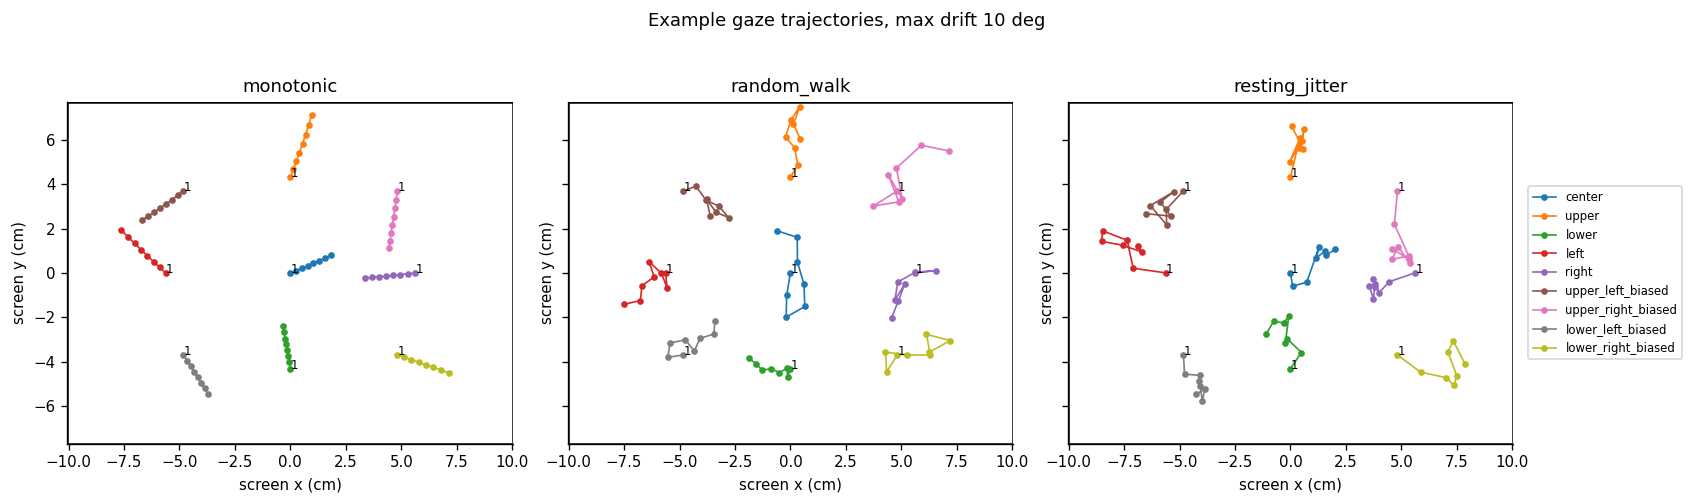

PosixPath('results/notebook_10/gaze_trajectory_examples.png')

In [10]:
def plot_gaze_trajectory_examples(gaze_df, config, output_dir):
    """Plot example gaze trajectories in screen coordinates."""
    max_mag = float(config["max_gaze_drift_deg"])
    plot_df = gaze_df[np.isclose(gaze_df["drift_magnitude_deg"], max_mag)].copy()
    starts = list(starting_screen_positions(config).keys())
    models = ["monotonic", "random_walk", "resting_jitter"]
    fig, axes = plt.subplots(
        1,
        len(models),
        figsize=(14.0, 4.2),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    if len(models) == 1:
        axes = [axes]
    for ax, model in zip(axes, models):
        sub_model = plot_df[plot_df["model"] == model]
        for start_label in starts:
            sub = sub_model[sub_model["start_label"] == start_label].sort_values("session")
            ax.plot(sub["x_cm"], sub["y_cm"], marker="o", ms=3, lw=1, label=start_label)
            if len(sub):
                ax.text(sub["x_cm"].iloc[0], sub["y_cm"].iloc[0], str(sub["session"].iloc[0]), fontsize=7)
        ax.set_title(model)
        ax.set_xlabel("screen x (cm)")
        ax.set_ylabel("screen y (cm)")
        ax.set_xlim(-config["screen_width_cm"] / 2, config["screen_width_cm"] / 2)
        ax.set_ylim(-config["screen_height_cm"] / 2, config["screen_height_cm"] / 2)
        ax.set_aspect("equal", adjustable="box")
        ax.add_patch(
            plt.Rectangle(
                (-config["screen_width_cm"] / 2, -config["screen_height_cm"] / 2),
                config["screen_width_cm"],
                config["screen_height_cm"],
                fill=False,
                lw=1.5,
            )
        )
    axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=7)
    fig.suptitle(f"Example gaze trajectories, max drift {max_mag:g} deg")
    path = output_dir / "gaze_trajectory_examples.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    return path


gaze_trajectory_path = plot_gaze_trajectory_examples(gaze_df, CONFIG, output_dir)
gaze_trajectory_path

## 7. Apparent preferred-orientation drift

Two readouts are implemented.

Readout A is a single-location / local-patch proxy. For each gaze trajectory, a stable neuron with a fixed intended preferred orientation is sampled at the screen point currently intersected by gaze. Its apparent preferred orientation is the true preferred orientation plus the local signed geometry-induced mismatch. Drift is reported relative to session 1.

Readout B is a population proxy. Each neuron has a stable retinotopic offset relative to gaze and a stable preferred orientation. Gaze moves across sessions, so the same retinotopic location intersects different screen coordinates. Only this geometry plus gaze sampling changes across sessions; the underlying tuning is fixed.

In [11]:
def signed_mismatch_at_points(x_cm, y_cm, ori_visual_deg, condition, config):
    """Evaluate signed geometry-induced orientation mismatch at point(s)."""
    label, assumed_distance_cm = condition_to_distance(condition, config)
    if assumed_distance_cm is None:
        screen_ori = ori_visual_deg
    else:
        screen_ori = local_orientation_on_screen_from_visual_orientation(
            x_cm,
            y_cm,
            ori_visual_deg,
            assumed_distance_cm,
            config,
        )
    actual = local_visual_orientation_from_screen_orientation(x_cm, y_cm, screen_ori, config)
    return signed_ori_diff_deg(actual, ori_visual_deg)


def simulate_local_patch_apparent_op(gaze_df, config, preferred_orientation_deg=45.0):
    """Compute single-patch apparent OP across gaze trajectories."""
    rows = []
    max_mag = float(config["max_gaze_drift_deg"])
    use_df = gaze_df[np.isclose(gaze_df["drift_magnitude_deg"], max_mag)].copy()

    for condition in config["assumed_distance_labels"]:
        for group_keys, sub in use_df.groupby(["model", "start_label"], sort=False):
            model, start_label = group_keys
            sub = sub.sort_values("session")
            signed = signed_mismatch_at_points(
                sub["x_cm"].to_numpy(),
                sub["y_cm"].to_numpy(),
                preferred_orientation_deg,
                condition,
                config,
            )
            signed = np.where(sub["in_bounds"].to_numpy(), signed, np.nan)
            apparent = wrap_ori_deg(preferred_orientation_deg + signed)
            first_valid = apparent[0] if np.isfinite(apparent[0]) else np.nan
            drift = ori_diff_deg(apparent, first_valid)
            for idx, row in sub.iterrows():
                j = int(row["session"]) - 1
                rows.append(
                    dict(
                        condition=condition,
                        model=model,
                        start_label=start_label,
                        drift_magnitude_deg=max_mag,
                        session=int(row["session"]),
                        x_cm=float(row["x_cm"]),
                        y_cm=float(row["y_cm"]),
                        in_bounds=bool(row["in_bounds"]),
                        true_preferred_orientation_deg=float(preferred_orientation_deg),
                        signed_mismatch_deg=float(signed[j]) if np.isfinite(signed[j]) else np.nan,
                        apparent_preferred_orientation_deg=float(apparent[j])
                        if np.isfinite(apparent[j])
                        else np.nan,
                        drift_from_session1_deg=float(drift[j]) if np.isfinite(drift[j]) else np.nan,
                    )
                )
    return pd.DataFrame(rows)


local_patch_df = simulate_local_patch_apparent_op(gaze_df, CONFIG, preferred_orientation_deg=45.0)
display(local_patch_df.head())
display(
    local_patch_df.groupby(["condition", "model"])["drift_from_session1_deg"]
    .agg(["median", lambda s: np.nanpercentile(s, 95), "max"])
    .rename(columns={"<lambda_0>": "p95"})
    .reset_index()
)

,condition,model,start_label,drift_magnitude_deg,session,x_cm,y_cm,in_bounds,true_preferred_orientation_deg,signed_mismatch_deg,apparent_preferred_orientation_deg,drift_from_session1_deg
0,no_correction,monotonic,center,10.0,1,0.000000,4.440892e-16,True,45.0,-2.465683,42.534317,0.000000
1,no_correction,monotonic,center,10.0,2,0.257685,1.037089e-01,True,45.0,-2.813873,42.186127,0.348189
2,no_correction,monotonic,center,10.0,3,0.515653,2.099461e-01,True,45.0,-3.164689,41.835311,0.699006
3,no_correction,monotonic,center,10.0,4,0.774189,3.189109e-01,True,45.0,-3.518358,41.481642,1.052675
4,no_correction,monotonic,center,10.0,5,1.033578,4.308118e-01,True,45.0,-3.875102,41.124898,1.409418


,condition,model,median,p95,max
0,correct_11cm,monotonic,0.000000,1.421085e-14,2.842171e-14
1,correct_11cm,random_walk,0.000000,1.421085e-14,1.421085e-14
2,correct_11cm,resting_jitter,0.000000,1.421085e-14,1.421085e-14
3,no_correction,monotonic,1.235090,5.940050e+00,8.089705e+00
4,no_correction,random_walk,1.042065,5.135221e+00,7.910405e+00
5,no_correction,resting_jitter,2.262941,7.884992e+00,9.417860e+00
6,over_16cm,monotonic,0.579768,2.498403e+00,3.499680e+00
7,over_16cm,random_walk,0.504751,1.883035e+00,3.466282e+00
8,over_16cm,resting_jitter,1.068444,3.173691e+00,3.935376e+00
9,under_6cm,monotonic,1.788831,5.023303e+00,7.400300e+00


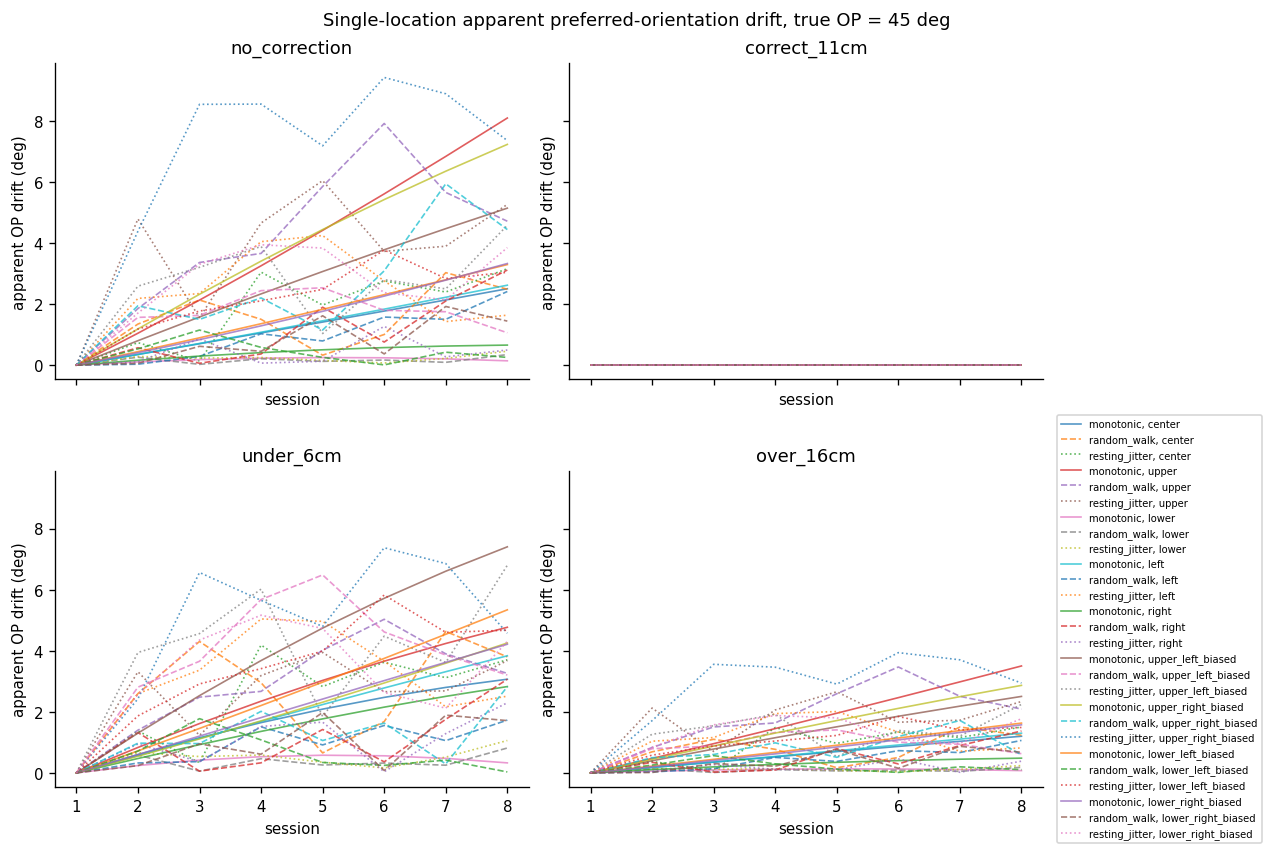

PosixPath('results/notebook_10/sessionwise_apparent_op_drift.png')

In [12]:
def plot_sessionwise_apparent_op_drift(local_patch_df, config, output_dir):
    """Plot local-patch apparent OP drift over sessions."""
    labels = list(config["assumed_distance_labels"])
    model_styles = {
        "monotonic": "-",
        "random_walk": "--",
        "resting_jitter": ":",
    }
    fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.0), sharex=True, sharey=True, constrained_layout=True)
    axes = axes.ravel()
    for ax, condition in zip(axes, labels):
        sub_cond = local_patch_df[local_patch_df["condition"] == condition]
        for (model, start_label), sub in sub_cond.groupby(["model", "start_label"], sort=False):
            sub = sub.sort_values("session")
            linestyle = model_styles.get(model, "-")
            ax.plot(
                sub["session"],
                sub["drift_from_session1_deg"],
                lw=1,
                alpha=0.75,
                linestyle=linestyle,
                label=f"{model}, {start_label}",
            )
        ax.set_title(condition)
        ax.set_xlabel("session")
        ax.set_ylabel("apparent OP drift (deg)")
        ax.set_xticks(range(1, int(config["n_sessions"]) + 1))
    handles, labels = axes[0].get_legend_handles_labels()
    axes[-1].legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=6)
    fig.suptitle("Single-location apparent preferred-orientation drift, true OP = 45 deg")
    path = output_dir / "sessionwise_apparent_op_drift.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    return path


sessionwise_path = plot_sessionwise_apparent_op_drift(local_patch_df, CONFIG, output_dir)
sessionwise_path

In [13]:
def simulate_population_apparent_op_drift(config):
    """Simulate geometry-induced apparent OP drift for a stable neural population.

    Each neuron receives:
    - a stable retinotopic offset in azimuth/elevation coordinates,
    - a stable true preferred orientation,
    - no neural tuning change across sessions.

    For each gaze trajectory, the neuron's retinotopic direction is intersected
    with the true screen, local geometry mismatch is evaluated, and apparent OP
    drift is measured relative to session 1.
    """
    rng = np.random.default_rng(config["random_seed"])
    n_neurons = int(config["n_neurons"])
    radius = float(config["rf_patch_radius_deg"])
    n_sessions = int(config["n_sessions"])

    r = radius * np.sqrt(rng.uniform(size=n_neurons))
    phi = rng.uniform(0.0, 2.0 * np.pi, size=n_neurons)
    rf_az_offset = r * np.cos(phi)
    rf_el_offset = r * np.sin(phi)
    true_pref = rng.uniform(0.0, 180.0, size=n_neurons)

    true_geom = geometry_from_config(config)
    gaze = simulate_gaze_trajectories(config)
    rows_neuron = []
    rows_session = []

    group_cols = ["model", "start_label", "drift_magnitude_deg"]
    for group_keys, traj in gaze.groupby(group_cols, sort=False):
        model, start_label, drift_mag = group_keys
        traj = traj.sort_values("session")

        sampled_x = np.full((n_sessions, n_neurons), np.nan)
        sampled_y = np.full((n_sessions, n_neurons), np.nan)
        sampled_in_bounds = np.zeros((n_sessions, n_neurons), dtype=bool)

        for session_idx, row in enumerate(traj.itertuples(index=False)):
            az = row.az_deg + rf_az_offset
            el = row.el_deg + rf_el_offset
            x, y, in_bounds = view_angles_to_screen_xy(az, el, true_geom)
            sampled_x[session_idx] = x
            sampled_y[session_idx] = y
            sampled_in_bounds[session_idx] = in_bounds

        for condition in config["assumed_distance_labels"]:
            apparent = np.full((n_sessions, n_neurons), np.nan)
            for session_idx in range(n_sessions):
                signed = signed_mismatch_at_points(
                    sampled_x[session_idx],
                    sampled_y[session_idx],
                    true_pref,
                    condition,
                    config,
                )
                valid = sampled_in_bounds[session_idx] & np.isfinite(signed)
                apparent[session_idx, valid] = wrap_ori_deg(true_pref[valid] + signed[valid])

            drift = ori_diff_deg(apparent, apparent[0][None, :])
            valid_fraction = np.mean(np.isfinite(drift), axis=0)
            max_drift = np.nanmax(drift, axis=0)
            final_drift = drift[-1]

            for session_idx in range(n_sessions):
                rows_session.append(
                    dict(
                        condition=condition,
                        model=model,
                        start_label=start_label,
                        drift_magnitude_deg=float(drift_mag),
                        session=session_idx + 1,
                        median_drift_deg=float(np.nanmedian(drift[session_idx])),
                        p95_drift_deg=float(np.nanpercentile(drift[session_idx], 95)),
                        max_drift_deg=float(np.nanmax(drift[session_idx])),
                        valid_fraction=float(np.mean(np.isfinite(drift[session_idx]))),
                    )
                )

            for neuron_idx in range(n_neurons):
                rows_neuron.append(
                    dict(
                        condition=condition,
                        model=model,
                        start_label=start_label,
                        drift_magnitude_deg=float(drift_mag),
                        neuron=neuron_idx,
                        true_pref_deg=float(true_pref[neuron_idx]),
                        rf_az_offset_deg=float(rf_az_offset[neuron_idx]),
                        rf_el_offset_deg=float(rf_el_offset[neuron_idx]),
                        max_drift_deg=float(max_drift[neuron_idx])
                        if np.isfinite(max_drift[neuron_idx])
                        else np.nan,
                        final_drift_deg=float(final_drift[neuron_idx])
                        if np.isfinite(final_drift[neuron_idx])
                        else np.nan,
                        valid_fraction=float(valid_fraction[neuron_idx]),
                    )
                )

    return pd.DataFrame(rows_neuron), pd.DataFrame(rows_session)


population_neuron_df, population_session_df = simulate_population_apparent_op_drift(CONFIG)
display(population_neuron_df.head())
display(population_session_df.head())

,condition,model,start_label,drift_magnitude_deg,neuron,true_pref_deg,rf_az_offset_deg,rf_el_offset_deg,max_drift_deg,final_drift_deg,valid_fraction
0,no_correction,monotonic,center,0.0,0,41.684358,2.688863,-2.897827,0.0,0.0,1.0
1,no_correction,monotonic,center,0.0,1,88.665639,3.408824,-3.287896,0.0,0.0,1.0
2,no_correction,monotonic,center,0.0,2,169.588567,-3.173749,-3.052779,0.0,0.0,1.0
3,no_correction,monotonic,center,0.0,3,131.193369,-2.351569,-0.316709,0.0,0.0,1.0
4,no_correction,monotonic,center,0.0,4,101.515022,0.839549,2.607549,0.0,0.0,1.0


,condition,model,start_label,drift_magnitude_deg,session,median_drift_deg,p95_drift_deg,max_drift_deg,valid_fraction
0,no_correction,monotonic,center,0.0,1,0.0,0.0,0.0,1.0
1,no_correction,monotonic,center,0.0,2,0.0,0.0,0.0,1.0
2,no_correction,monotonic,center,0.0,3,0.0,0.0,0.0,1.0
3,no_correction,monotonic,center,0.0,4,0.0,0.0,0.0,1.0
4,no_correction,monotonic,center,0.0,5,0.0,0.0,0.0,1.0


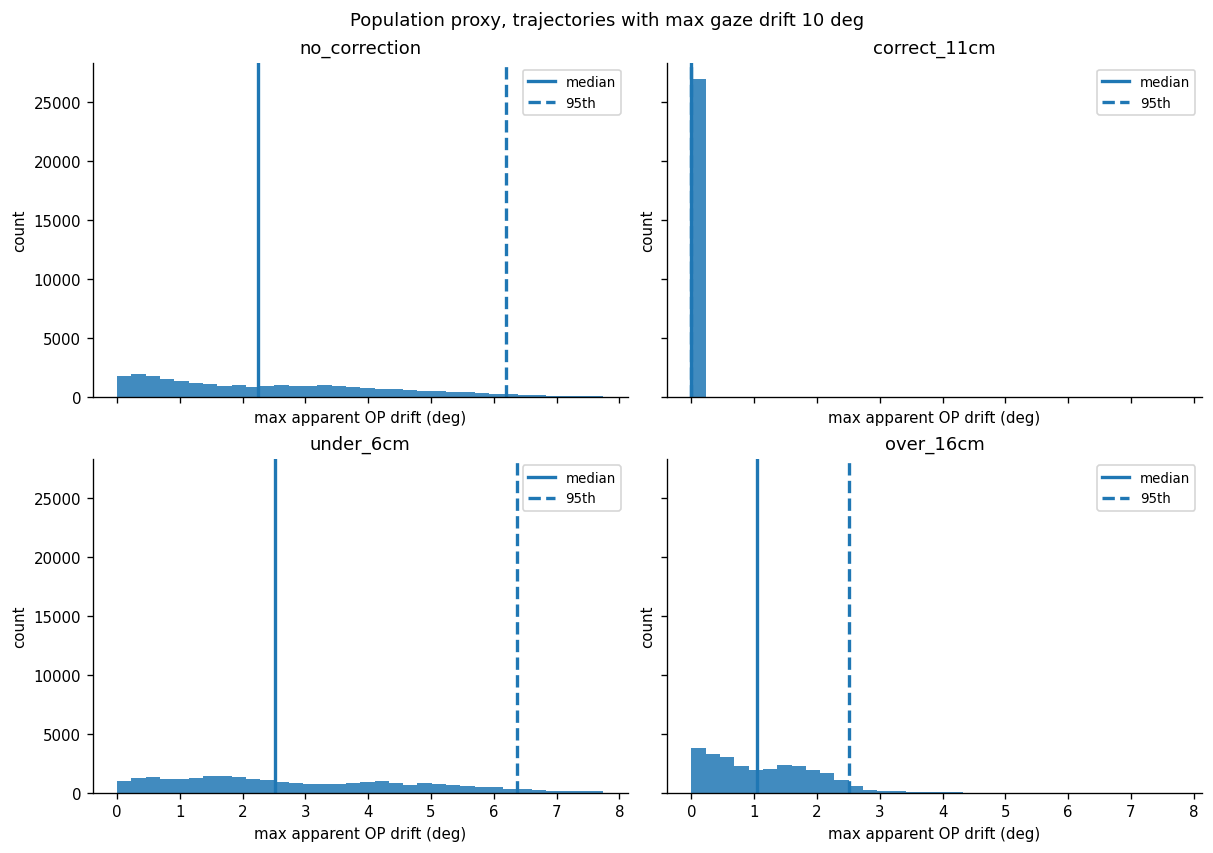

PosixPath('results/notebook_10/population_apparent_op_drift_distribution.png')

In [14]:
def plot_population_apparent_op_drift_distribution(population_neuron_df, config, output_dir):
    """Plot distributions of per-neuron maximum apparent OP drift."""
    max_mag = float(config["max_gaze_drift_deg"])
    sub = population_neuron_df[
        np.isclose(population_neuron_df["drift_magnitude_deg"], max_mag)
        & (population_neuron_df["valid_fraction"] > 0.5)
    ].copy()
    labels = list(config["assumed_distance_labels"])
    fig, axes = plt.subplots(2, 2, figsize=(10.0, 7.0), sharex=True, sharey=True, constrained_layout=True)
    axes = axes.ravel()
    bins = np.linspace(0, max(1.0, np.nanpercentile(sub["max_drift_deg"], 99.5)), 35)
    for ax, condition in zip(axes, labels):
        vals = sub[sub["condition"] == condition]["max_drift_deg"].dropna().to_numpy()
        ax.hist(vals, bins=bins, alpha=0.85)
        ax.axvline(np.nanmedian(vals), lw=2, label="median")
        ax.axvline(np.nanpercentile(vals, 95), lw=2, linestyle="--", label="95th")
        ax.set_title(condition)
        ax.set_xlabel("max apparent OP drift (deg)")
        ax.set_ylabel("count")
        ax.legend(fontsize=8)
    fig.suptitle(f"Population proxy, trajectories with max gaze drift {max_mag:g} deg")
    path = output_dir / "population_apparent_op_drift_distribution.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    return path


population_distribution_path = plot_population_apparent_op_drift_distribution(
    population_neuron_df,
    CONFIG,
    output_dir,
)
population_distribution_path

## 8. Summary and interpretation

The summary table combines two quantities:

- Screen-wide orientation error: pooled across all canonical orientations and all screen grid positions.
- Population apparent OP drift: per-neuron maximum drift across sessions for trajectories with 10 deg maximum gaze drift, pooled across starting positions and both trajectory models.

This makes the table a compact upper-use-case summary rather than a claim about any particular animal's gaze distribution.

In [15]:
def summarize_results(surface_results, population_neuron_summary, config):
    """Create one-row-per-condition summary table for orientation errors and OP drift."""
    max_mag = float(config["max_gaze_drift_deg"])
    rows = []
    for label in config["assumed_distance_labels"]:
        screen_errors = []
        for ori in config["canonical_orientations_deg"]:
            screen_errors.append(surface_results[(label, float(ori))]["error_deg"].ravel())
        screen_errors = np.concatenate(screen_errors)

        pop = population_neuron_summary[
            (population_neuron_summary["condition"] == label)
            & np.isclose(population_neuron_summary["drift_magnitude_deg"], max_mag)
            & (population_neuron_summary["valid_fraction"] > 0.5)
        ]["max_drift_deg"].dropna()

        rows.append(
            dict(
                condition=label,
                median_orientation_error_across_screen_deg=float(np.nanmedian(screen_errors)),
                p95_orientation_error_across_screen_deg=float(np.nanpercentile(screen_errors, 95)),
                median_apparent_op_drift_across_neurons_deg=float(np.nanmedian(pop)),
                p95_apparent_op_drift_across_neurons_deg=float(np.nanpercentile(pop, 95)),
                max_apparent_op_drift_across_neurons_deg=float(np.nanmax(pop)),
            )
        )

    return pd.DataFrame(rows)


summary_df = summarize_results(surface_results, population_neuron_df, CONFIG)
display(summary_df)

,condition,median_orientation_error_across_screen_deg,p95_orientation_error_across_screen_deg,median_apparent_op_drift_across_neurons_deg,p95_apparent_op_drift_across_neurons_deg,max_apparent_op_drift_across_neurons_deg
0,no_correction,2.781666,1.750298e+01,2.250980e+00,6.189715e+00,1.076487e+01
1,correct_11cm,0.000000,2.842171e-14,1.421085e-14,4.263256e-14,8.526513e-14
2,under_6cm,4.157757,1.585447e+01,2.509650e+00,6.370422e+00,9.259418e+00
3,over_16cm,1.355982,7.286169e+00,1.037865e+00,2.512774e+00,4.291821e+00


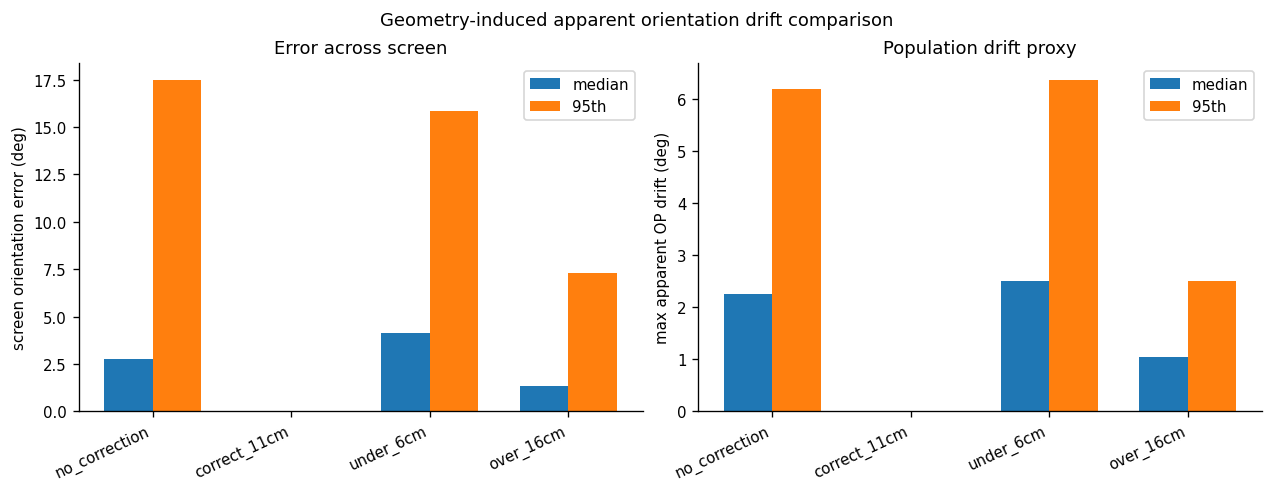

PosixPath('results/notebook_10/summary_comparison.png')

In [16]:
def plot_summary_comparison(summary_df, output_dir):
    """Plot compact condition comparison for screen error and apparent OP drift."""
    labels = summary_df["condition"].to_list()
    x = np.arange(len(labels))
    width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), constrained_layout=True)

    axes[0].bar(
        x - width / 2,
        summary_df["median_orientation_error_across_screen_deg"],
        width,
        label="median",
    )
    axes[0].bar(
        x + width / 2,
        summary_df["p95_orientation_error_across_screen_deg"],
        width,
        label="95th",
    )
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=25, ha="right")
    axes[0].set_ylabel("screen orientation error (deg)")
    axes[0].set_title("Error across screen")
    axes[0].legend()

    axes[1].bar(
        x - width / 2,
        summary_df["median_apparent_op_drift_across_neurons_deg"],
        width,
        label="median",
    )
    axes[1].bar(
        x + width / 2,
        summary_df["p95_apparent_op_drift_across_neurons_deg"],
        width,
        label="95th",
    )
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=25, ha="right")
    axes[1].set_ylabel("max apparent OP drift (deg)")
    axes[1].set_title("Population drift proxy")
    axes[1].legend()

    fig.suptitle("Geometry-induced apparent orientation drift comparison")
    path = output_dir / "summary_comparison.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    return path


summary_comparison_path = plot_summary_comparison(summary_df, output_dir)
summary_comparison_path

In [17]:
best_label = "correct_11cm"
no_label = "no_correction"
under_label = "under_6cm"
over_label = "over_16cm"

def row_value(label, column):
    return float(summary_df.loc[summary_df["condition"] == label, column].iloc[0])

interpretation = f"""
**Plain-English interpretation**

In this geometry-only simulation with stable underlying tuning, 10 deg gaze drift can induce apparent preferred-orientation drift when the local orientation error changes across sampled screen positions.

For the population proxy, median maximum apparent OP drift was {row_value(no_label, "median_apparent_op_drift_across_neurons_deg"):.2f} deg without correction, {row_value(best_label, "median_apparent_op_drift_across_neurons_deg"):.2f} deg with correct 11 cm correction, {row_value(under_label, "median_apparent_op_drift_across_neurons_deg"):.2f} deg when assuming 6 cm, and {row_value(over_label, "median_apparent_op_drift_across_neurons_deg"):.2f} deg when assuming 16 cm.

Correct correction helps because it makes the rendered screen image locally consistent with the intended visual-angle grating; remaining values are numerical roundoff and finite grid effects. A +/-5 cm distance mismatch reintroduces spatially varying local orientation errors, so gaze drift can become apparent OP drift even without neural change.

Errors are largest away from the screen center, especially toward peripheral and vertically offset screen regions where the flat screen subtends rapidly changing azimuth/elevation geometry. The exact sign and magnitude depend on the intended orientation and the direction of gaze drift.
"""
display(Markdown(interpretation))


**Plain-English interpretation**

In this geometry-only simulation with stable underlying tuning, 10 deg gaze drift can induce apparent preferred-orientation drift when the local orientation error changes across sampled screen positions.

For the population proxy, median maximum apparent OP drift was 2.25 deg without correction, 0.00 deg with correct 11 cm correction, 2.51 deg when assuming 6 cm, and 1.04 deg when assuming 16 cm.

Correct correction helps because it makes the rendered screen image locally consistent with the intended visual-angle grating; remaining values are numerical roundoff and finite grid effects. A +/-5 cm distance mismatch reintroduces spatially varying local orientation errors, so gaze drift can become apparent OP drift even without neural change.

Errors are largest away from the screen center, especially toward peripheral and vertically offset screen regions where the flat screen subtends rapidly changing azimuth/elevation geometry. The exact sign and magnitude depend on the intended orientation and the direction of gaze drift.


## 9. Checks, caveats, and possible failure modes

The validation checks below are intentionally concrete:

- The screen center should map to azimuth near 0 deg and elevation near `atan2(3.3, 11)`.
- The orientation-difference function should behave modulo 180 deg.
- Correct 11 cm correction should produce less central distortion than no correction, especially for oblique orientations.
- Wrong-distance correction should produce larger off-center errors than correct correction.

Caveats:

- This is a geometry-based simulation.
- It does not prove real tuning drift is geometric.
- It estimates how much drift could arise without any neural change.
- It treats the display correction as a local azimuth/elevation pullback. If the real BonVision shader uses a different spherical coordinate convention, the coordinate definitions here should be updated to match it exactly.
- It does not model eye optics, monitor pixel discretization, retinal magnification, binocular effects, temporal dynamics, or neural tuning nonlinearities.

In [18]:
# Validation checks and explicit printed results.
print("Validation checks")
print("-----------------")

center_az, center_el = screen_to_view_angles(0.0, 0.0, CONFIG)
expected_center_az = 0.0
expected_center_el = np.degrees(np.arctan2(3.3, 11.0))
print(f"Center azimuth:  observed {center_az:.6f} deg, expected {expected_center_az:.6f} deg")
print(f"Center elevation: observed {center_el:.6f} deg, expected {expected_center_el:.6f} deg")

diff_tests = [
    (0.0, 179.0, 1.0),
    (10.0, 170.0, 20.0),
    (45.0, 45.0, 0.0),
    (0.0, 90.0, 90.0),
    (135.0, -45.0, 0.0),
]
for a, b, expected in diff_tests:
    observed = float(ori_diff_deg(a, b))
    print(f"ori_diff_deg({a:g}, {b:g}) = {observed:.6f} deg, expected {expected:.6f} deg")

xs, ys, X, Y = screen_grid_cm(CONFIG)
radius = np.sqrt(X * X + Y * Y)
center_mask = radius <= 2.0
edge_mask = radius >= np.nanpercentile(radius, 80)

center_no = []
center_correct = []
edge_correct = []
edge_under = []
edge_over = []
for ori in CONFIG["canonical_orientations_deg"]:
    center_no.append(surface_results[("no_correction", float(ori))]["error_deg"][center_mask])
    center_correct.append(surface_results[("correct_11cm", float(ori))]["error_deg"][center_mask])
    edge_correct.append(surface_results[("correct_11cm", float(ori))]["error_deg"][edge_mask])
    edge_under.append(surface_results[("under_6cm", float(ori))]["error_deg"][edge_mask])
    edge_over.append(surface_results[("over_16cm", float(ori))]["error_deg"][edge_mask])

center_no_mean = float(np.nanmean(np.concatenate(center_no)))
center_correct_mean = float(np.nanmean(np.concatenate(center_correct)))
edge_correct_p95 = float(np.nanpercentile(np.concatenate(edge_correct), 95))
edge_under_p95 = float(np.nanpercentile(np.concatenate(edge_under), 95))
edge_over_p95 = float(np.nanpercentile(np.concatenate(edge_over), 95))

print(f"Central mean error, no correction: {center_no_mean:.6f} deg")
print(f"Central mean error, correct 11 cm: {center_correct_mean:.6f} deg")
print(f"Off-center p95 error, correct 11 cm: {edge_correct_p95:.6f} deg")
print(f"Off-center p95 error, assumed 6 cm: {edge_under_p95:.6f} deg")
print(f"Off-center p95 error, assumed 16 cm: {edge_over_p95:.6f} deg")

validation = {
    "center_az_ok": bool(np.isclose(center_az, expected_center_az, atol=1e-9)),
    "center_el_ok": bool(np.isclose(center_el, expected_center_el, atol=1e-9)),
    "ori_diff_ok": bool(all(np.isclose(float(ori_diff_deg(a, b)), expected) for a, b, expected in diff_tests)),
    "correct_less_than_no_central": bool(center_correct_mean < center_no_mean),
    "wrong_distance_larger_than_correct_edges": bool(
        (edge_under_p95 > edge_correct_p95) and (edge_over_p95 > edge_correct_p95)
    ),
}
print(validation)

display(Markdown("This notebook estimates geometry-induced apparent orientation drift under gaze drift and display correction mismatch, assuming stable underlying neural tuning."))

Validation checks
-----------------
Center azimuth:  observed 0.000000 deg, expected 0.000000 deg
Center elevation: observed 16.699244 deg, expected 16.699244 deg
ori_diff_deg(0, 179) = 1.000000 deg, expected 1.000000 deg
ori_diff_deg(10, 170) = 20.000000 deg, expected 20.000000 deg
ori_diff_deg(45, 45) = 0.000000 deg, expected 0.000000 deg
ori_diff_deg(0, 90) = 90.000000 deg, expected 90.000000 deg
ori_diff_deg(135, -45) = 0.000000 deg, expected 0.000000 deg
Central mean error, no correction: 1.554595 deg
Central mean error, correct 11 cm: 0.000000 deg
Off-center p95 error, correct 11 cm: 0.000000 deg
Off-center p95 error, assumed 6 cm: 15.724980 deg
Off-center p95 error, assumed 16 cm: 8.241070 deg
{'center_az_ok': True, 'center_el_ok': True, 'ori_diff_ok': True, 'correct_less_than_no_central': True, 'wrong_distance_larger_than_correct_edges': True}


This notebook estimates geometry-induced apparent orientation drift under gaze drift and display correction mismatch, assuming stable underlying neural tuning.